# Air Quality — EDA tabele `measurements` (sa zaključcima ispod grafika)

In [2]:
import os
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100

findings = []

def add_finding(text):
    findings.append(text)
    print("ZAKLJUČAK:", text)


## 1. Učitavanje podataka



In [3]:
candidate_paths = [
    os.path.join("..", "data", "processed", "air_quality.db"),
    os.path.join("data", "processed", "air_quality.db"),
    "air_quality.db",
]
DB_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)

conn = sqlite3.connect(DB_PATH)
existing_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)["name"].tolist()
print("Tabele u bazi:", existing_tables)


Tabele u bazi: ['measurements', 'sensors', 'daily_city_avg', 'monthly_city_avg', 'aqi', 'daily_city_aqi']


In [4]:
NON_MEASUREMENT_COLUMNS = {
    "device_id", "timestamp", "latitude", "longitude",
    "source_dataset", "source_file",
}

existing_cols = pd.read_sql("PRAGMA table_info(measurements)", conn)["name"].tolist()
measure_cols = [c for c in existing_cols if c not in NON_MEASUREMENT_COLUMNS]

query = f"""
SELECT m.device_id, m.timestamp, s.city, s.region, s.country_code,
       {", ".join("m." + c for c in measure_cols)}
FROM measurements m
JOIN sensors s ON m.device_id = s.device_id
"""
df = pd.read_sql(query, conn)

for col in measure_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True).dt.tz_convert("Europe/Belgrade")

print(f"Učitano {len(df):,} redova, {len(measure_cols)} kolona sa merenjima")
df.head()


Učitano 136,145 redova, 19 kolona sa merenjima


,device_id,timestamp,city,region,country_code,pm1_raw,pm1_number_conc,pm25_raw,pm25_number_conc,pm25_nowcast_aqi_epa,pm25_24h_raw,pm25_24h_number_conc,pm25_aqi_dwer,pm10_raw,pm10_number_conc,pm10_24h_raw,pm10_24h_number_conc,pm10_aqi_dwer,no2_raw,no2_aqi_epa,no2_aqi_dwer,o3_raw,temp_internal,humidity_internal
0,AC8QFXSV,2023-03-01 13:00:00+01:00,Sjenica,Central Serbia,RS,1.83,4.46,5.80,4.66,35.0,13.28,9.95,6.0,7.85,4.74,17.33,10.06,8.0,5.54,5.0,6.0,NaN,7.35,72.08
1,AHVMMMWN,2023-03-01 13:00:00+01:00,Bela Palanka,Central Serbia,RS,10.96,14.72,17.47,15.44,65.0,64.67,57.18,17.0,19.24,15.52,93.57,58.01,19.0,2.67,3.0,3.0,NaN,10.53,64.44
2,A0VTV4M9,2023-03-01 13:00:00+01:00,Kragujevac,Central Serbia,RS,12.69,15.14,21.32,15.93,110.0,73.36,49.40,21.0,26.54,16.08,106.81,50.24,27.0,0.07,0.0,0.0,NaN,9.37,68.34
3,A3QK8XR1,2023-03-01 13:00:00+01:00,Kragujevac,Central Serbia,RS,13.78,23.51,22.12,24.82,99.0,43.43,50.73,22.0,30.20,25.04,61.39,51.30,30.0,11.28,11.0,11.0,NaN,20.90,34.29
4,A3QK8XR1,2022-04-30 18:00:00+02:00,Kragujevac,Central Serbia,RS,6.38,11.61,9.25,12.11,44.0,24.93,29.08,9.0,11.76,12.17,32.00,29.27,12.0,2.51,2.0,3.0,NaN,21.23,39.41


## 2. Nedostajući podaci

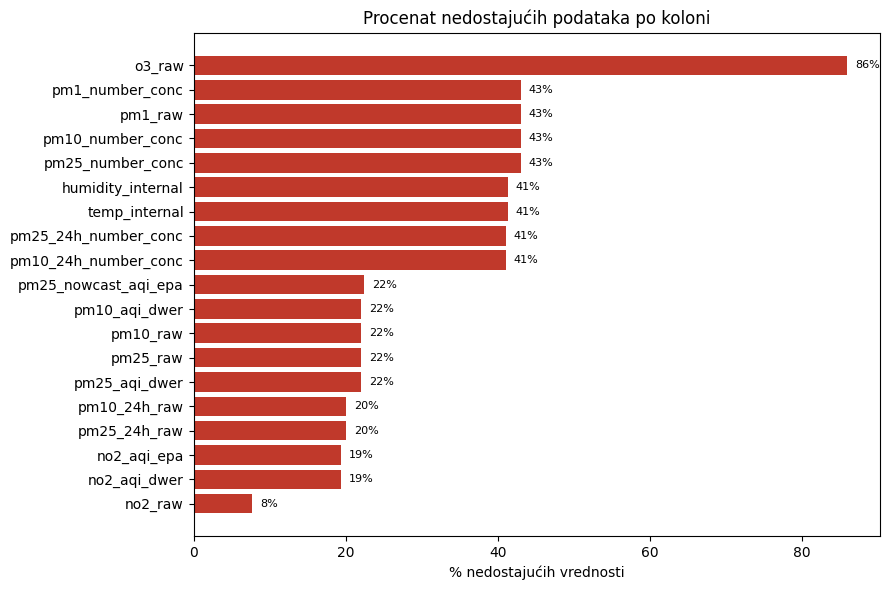

ZAKLJUČAK: Kolona sa najviše praznina je 'o3_raw' (86% nedostaje) — 


In [5]:
missing = df[measure_cols].isna().mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(missing.index, missing.values, color="#c0392b")
ax.set_xlabel("% nedostajućih vrednosti")
ax.set_title("Procenat nedostajućih podataka po koloni")
ax.invert_yaxis()
for b, v in zip(bars, missing.values):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

worst_col = missing.idxmax()
add_finding(
    f"Kolona sa najviše praznina je '{worst_col}' ({missing.max():.0f}% nedostaje) — "
    ""
)


## 3. Deskriptivna statistika

In [6]:
desc = df[measure_cols].describe().T
desc["missing_pct"] = df[measure_cols].isna().mean() * 100
desc["skew"] = df[measure_cols].skew()
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing_pct", "skew"]]
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,missing_pct,skew
pm1_raw,77540.0,21.57,19.67,0.00,9.22,16.44,27.94,461.86,43.05,2.95
pm1_number_conc,77540.0,35.11,32.70,0.17,15.87,25.62,42.53,403.67,43.05,2.83
pm25_raw,106149.0,31.71,31.83,0.00,11.84,22.17,40.90,586.52,22.03,3.28
pm25_number_conc,77540.0,36.95,34.67,0.18,16.55,26.86,44.82,422.26,43.05,2.85
pm25_nowcast_aqi_epa,105585.0,84.13,47.80,0.00,52.00,73.00,114.00,490.00,22.45,0.85
pm25_24h_raw,108824.0,32.52,26.54,0.73,14.38,24.50,41.92,307.97,20.07,2.01
pm25_24h_number_conc,80215.0,37.40,27.74,0.68,19.61,29.34,47.35,266.33,41.08,2.03
pm25_aqi_dwer,106149.0,31.71,31.83,0.00,12.00,22.00,41.00,587.00,22.03,3.28
pm10_raw,106147.0,41.30,44.42,0.00,14.93,26.91,52.26,919.19,22.03,3.68
pm10_number_conc,77540.0,37.28,35.06,0.21,16.65,27.04,45.22,424.04,43.05,2.85


In [7]:
most_skewed = desc["skew"].abs().idxmax()
add_finding(
    f"Kolona '{most_skewed}' ima najizraženiju asimetriju raspodele (skew={desc.loc[most_skewed, 'skew']:.1f}) "
)


ZAKLJUČAK: Kolona 'no2_aqi_dwer' ima najizraženiju asimetriju raspodele (skew=3.7) 


## 4. Distribucije i outlieri

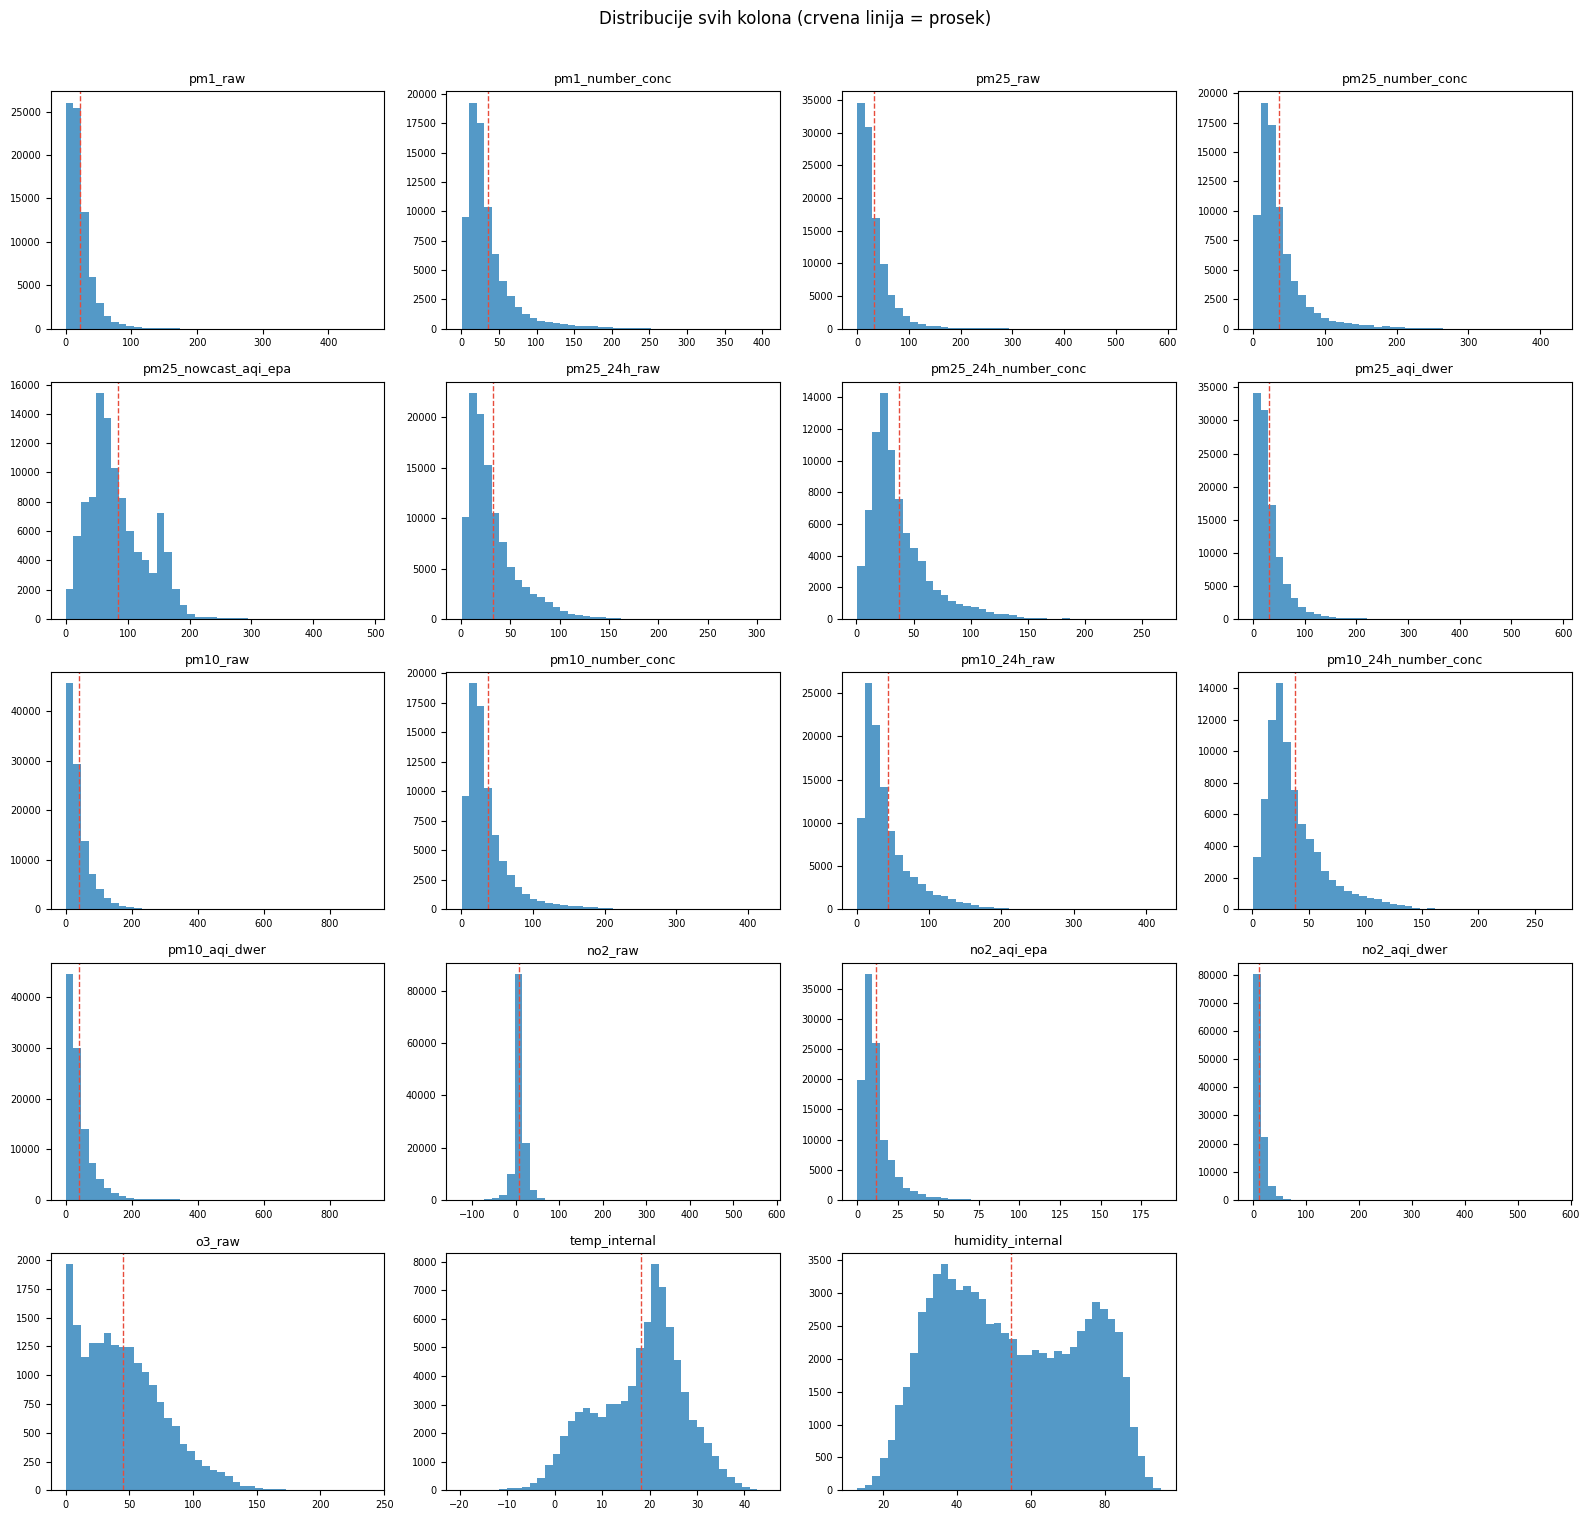

In [8]:
n_cols = len(measure_cols)
n_grid_cols = 4
n_grid_rows = int(np.ceil(n_cols / n_grid_cols))

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(16, 3 * n_grid_rows))
axes = axes.flatten()

for i, col in enumerate(measure_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color="#2980b9", alpha=0.8)
    axes[i].axvline(data.mean(), color="#e74c3c", linestyle="--", linewidth=1)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribucije svih kolona (crvena linija = prosek)", y=1.01)
plt.tight_layout()
plt.show()


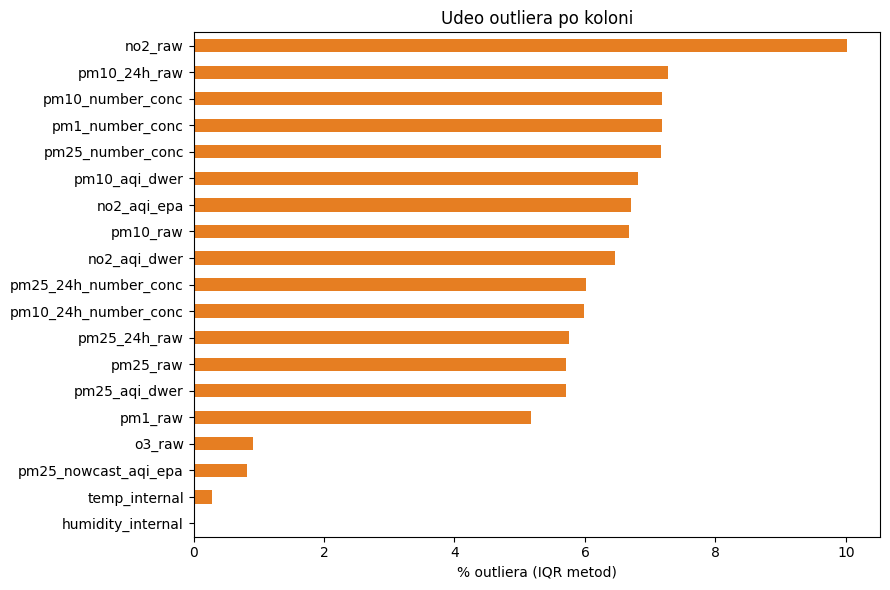

ZAKLJUČAK: Kolona 'no2_raw' ima najveći udeo outliera (10.0%) po IQR metodu — kandidat za detaljniju proveru grešaka senzora ili ekstremnih epizoda zagađenja.
ZAKLJUČAK: Broj redova gde je pm10_raw < pm25_raw (fizički nemoguće): 368 (0.27% od svih redova).


In [9]:
def iqr_outlier_pct(series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

outlier_pct = pd.Series({c: iqr_outlier_pct(df[c]) for c in measure_cols}, name="outlier_pct_iqr")
top_outlier_col = outlier_pct.idxmax()

fig, ax = plt.subplots(figsize=(9, 6))
outlier_pct.sort_values().plot(kind="barh", ax=ax, color="#e67e22")
ax.set_xlabel("% outliera (IQR metod)")
ax.set_title("Udeo outliera po koloni")
plt.tight_layout()
plt.show()

add_finding(
    f"Kolona '{top_outlier_col}' ima najveći udeo outliera ({outlier_pct.max():.1f}%) "
    "po IQR metodu — kandidat za detaljniju proveru grešaka senzora ili ekstremnih epizoda zagađenja."
)

bad_pm = (df["pm10_raw"] < df["pm25_raw"]).sum()
add_finding(
    f"Broj redova gde je pm10_raw < pm25_raw (fizički nemoguće): {bad_pm} "
    f"({bad_pm / len(df) * 100:.2f}% od svih redova)."
)


## 5. Korelaciona matrica — sa istaknutim najjačim vezama

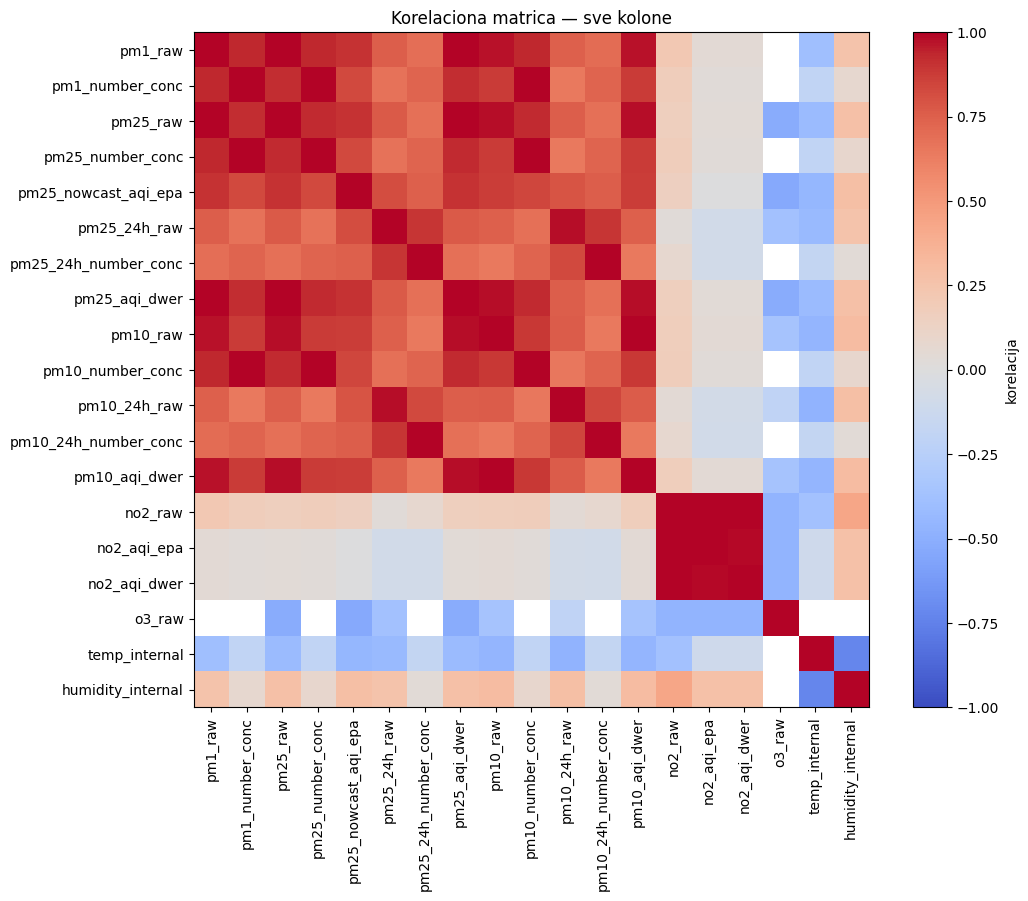

In [11]:
corr = df[measure_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
plt.colorbar(im, label="korelacija")
ax.set_title("Korelaciona matrica — sve kolone")
plt.tight_layout()
plt.show()


In [12]:
# Najjači par (van dijagonale) 
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strongest_pair = corr_pairs.abs().idxmax()
strongest_val = corr_pairs[strongest_pair]

add_finding(
    f"Najjača korelacija u celoj matrici je između '{strongest_pair[0]}' i '{strongest_pair[1]}' "
    f"(r={strongest_val:.2f}) — {'očekivano, iste su fizičke veličine izvedene jedna iz druge' if strongest_val > 0.9 else 'vredi proveriti da li je uzročno-posledična veza ili slučajnost'}."
)

for target in [c for c in ["pm25_raw", "pm10_raw", "no2_raw", "o3_raw"] if c in corr.columns]:
    top = corr[target].drop(target).abs().idxmax()
    add_finding(
        f"'{target}' najjače korelira sa '{top}' (r={corr.loc[target, top]:.2f})."
    )


ZAKLJUČAK: Najjača korelacija u celoj matrici je između 'pm25_24h_number_conc' i 'pm10_24h_number_conc' (r=1.00) — očekivano, iste su fizičke veličine izvedene jedna iz druge.
ZAKLJUČAK: 'pm25_raw' najjače korelira sa 'pm25_aqi_dwer' (r=1.00).
ZAKLJUČAK: 'pm10_raw' najjače korelira sa 'pm10_aqi_dwer' (r=1.00).
ZAKLJUČAK: 'no2_raw' najjače korelira sa 'no2_aqi_dwer' (r=1.00).
ZAKLJUČAK: 'o3_raw' najjače korelira sa 'pm25_nowcast_aqi_epa' (r=-0.53).


## 6. Dnevni, nedeljni i sezonski obrazac — sa označenim pikovima

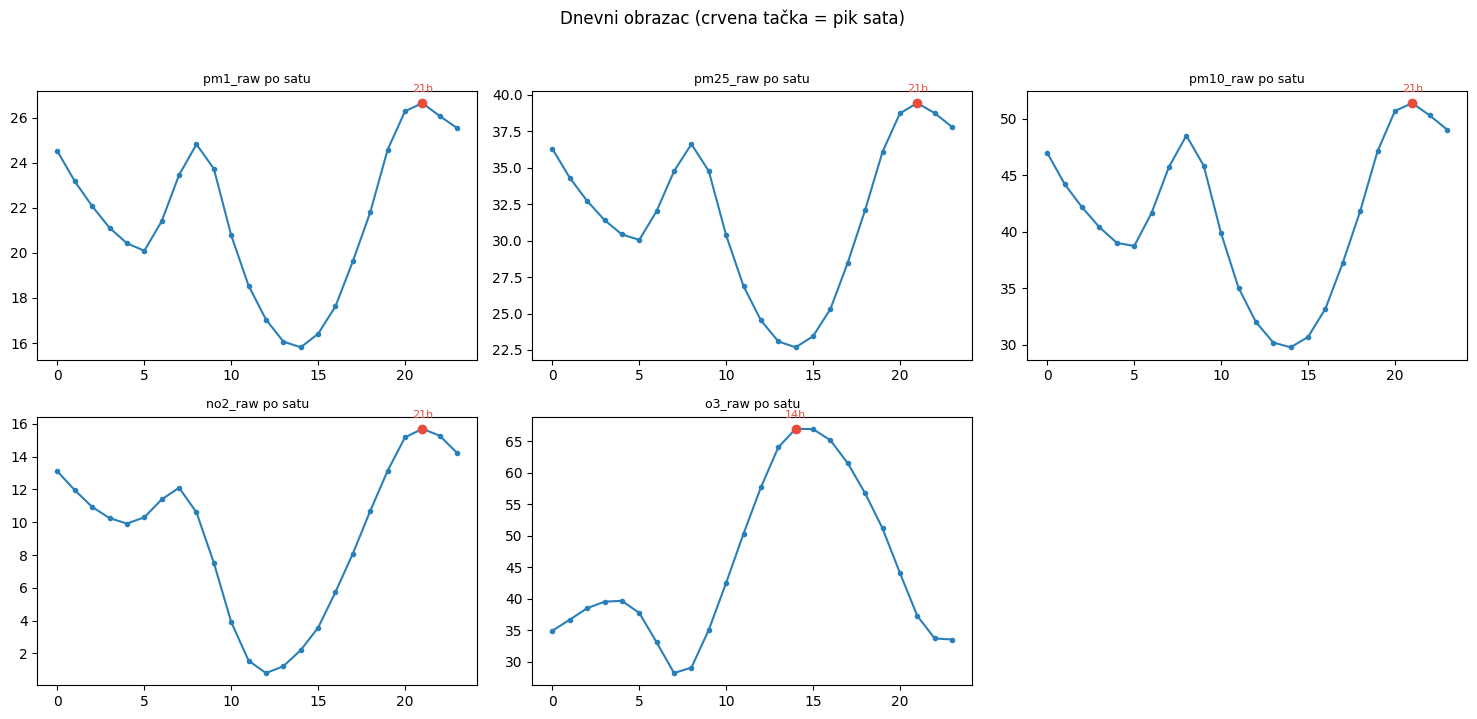

ZAKLJUČAK: PM2.5 dostiže dnevni maksimum oko 21h (39.4 µg/m³) — konzistentno sa loženjem/saobraćajem u jutarnjim/večernjim satima, u zavisnosti od sezone.


In [13]:
raw_cols = [c for c in measure_cols if c.endswith("_raw") and "24h" not in c]

df["hour"] = df["timestamp"].dt.hour
diurnal = df.groupby("hour")[raw_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(raw_cols):
    axes[i].plot(diurnal.index, diurnal[col], color="#2980b9", marker="o", markersize=3)
    peak_hour = diurnal[col].idxmax()
    peak_val = diurnal[col].max()
    axes[i].scatter([peak_hour], [peak_val], color="#e74c3c", zorder=5)
    axes[i].annotate(f"{peak_hour}h", (peak_hour, peak_val), textcoords="offset points",
                      xytext=(0, 8), ha="center", fontsize=8, color="#e74c3c")
    axes[i].set_title(f"{col} po satu", fontsize=9)
for j in range(len(raw_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Dnevni obrazac (crvena tačka = pik sata)", y=1.02)
plt.tight_layout()
plt.show()

pm25_peak_hour = diurnal["pm25_raw"].idxmax()
add_finding(
    f"PM2.5 dostiže dnevni maksimum oko {pm25_peak_hour}h "
    f"({diurnal['pm25_raw'].max():.1f} µg/m³) — konzistentno sa loženjem/saobraćajem "
    "u jutarnjim/večernjim satima, u zavisnosti od sezone."
)


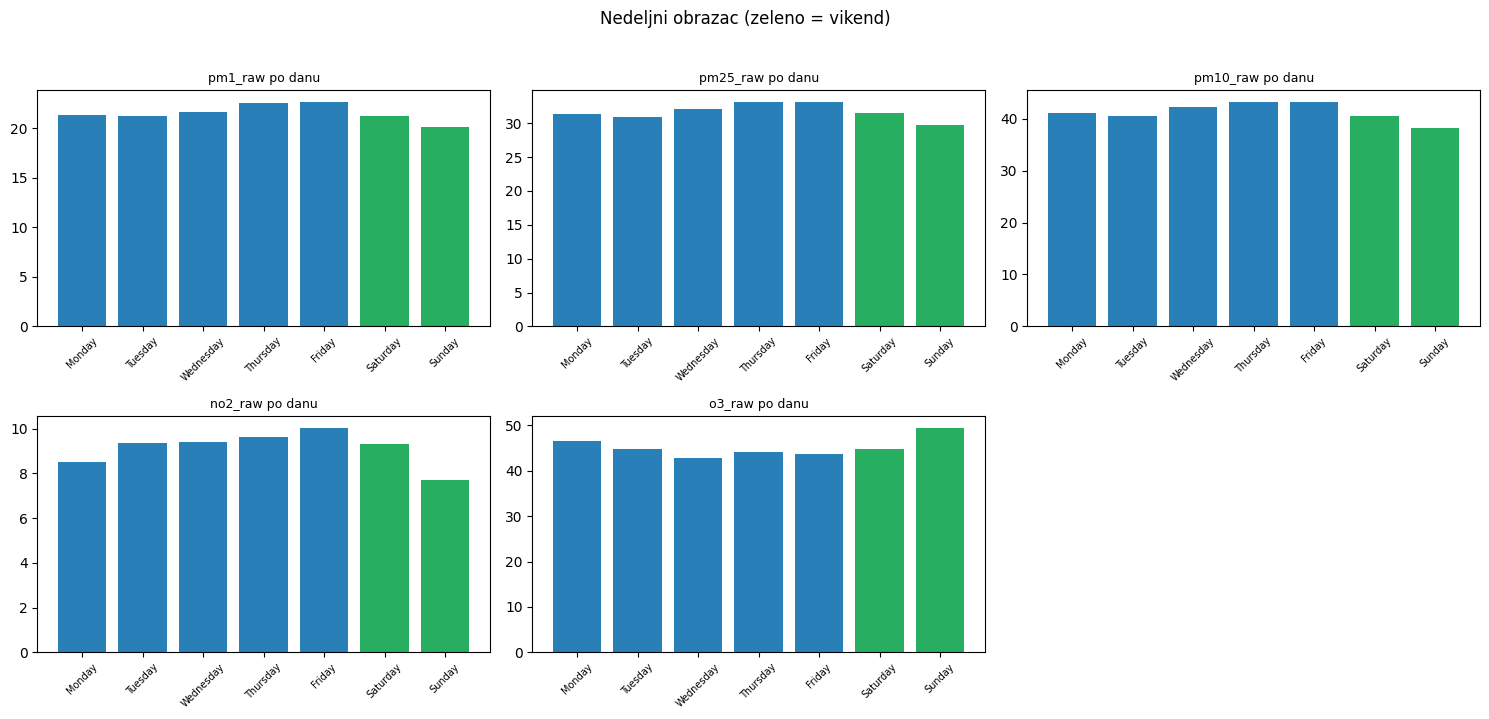

ZAKLJUČAK: PM2.5 je radnim danima u proseku viši za 5% u odnosu na vikend (32.1 vs 30.6 µg/m³) — sugeriše uticaj saobraćaja/industrije radnim danima.


In [14]:
df["dayofweek"] = df["timestamp"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = df.groupby("dayofweek")[raw_cols].mean().reindex(day_order)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(raw_cols):
    colors = ["#2980b9"] * 5 + ["#27ae60"] * 2  # radni dani plavo, vikend zeleno
    axes[i].bar(weekly.index, weekly[col], color=colors)
    axes[i].set_title(f"{col} po danu", fontsize=9)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
for j in range(len(raw_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Nedeljni obrazac (zeleno = vikend)", y=1.02)
plt.tight_layout()
plt.show()

weekday_avg = weekly.loc[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"], "pm25_raw"].mean()
weekend_avg = weekly.loc[["Saturday", "Sunday"], "pm25_raw"].mean()
diff_pct = (weekday_avg - weekend_avg) / weekend_avg * 100
add_finding(
    f"PM2.5 je radnim danima u proseku {'viši' if diff_pct > 0 else 'niži'} za {abs(diff_pct):.0f}% "
    f"u odnosu na vikend ({weekday_avg:.1f} vs {weekend_avg:.1f} µg/m³) — "
    f"{'sugeriše uticaj saobraćaja/industrije radnim danima' if diff_pct > 5 else 'razlika je premala da bi bila pouzdan signal'}."
)


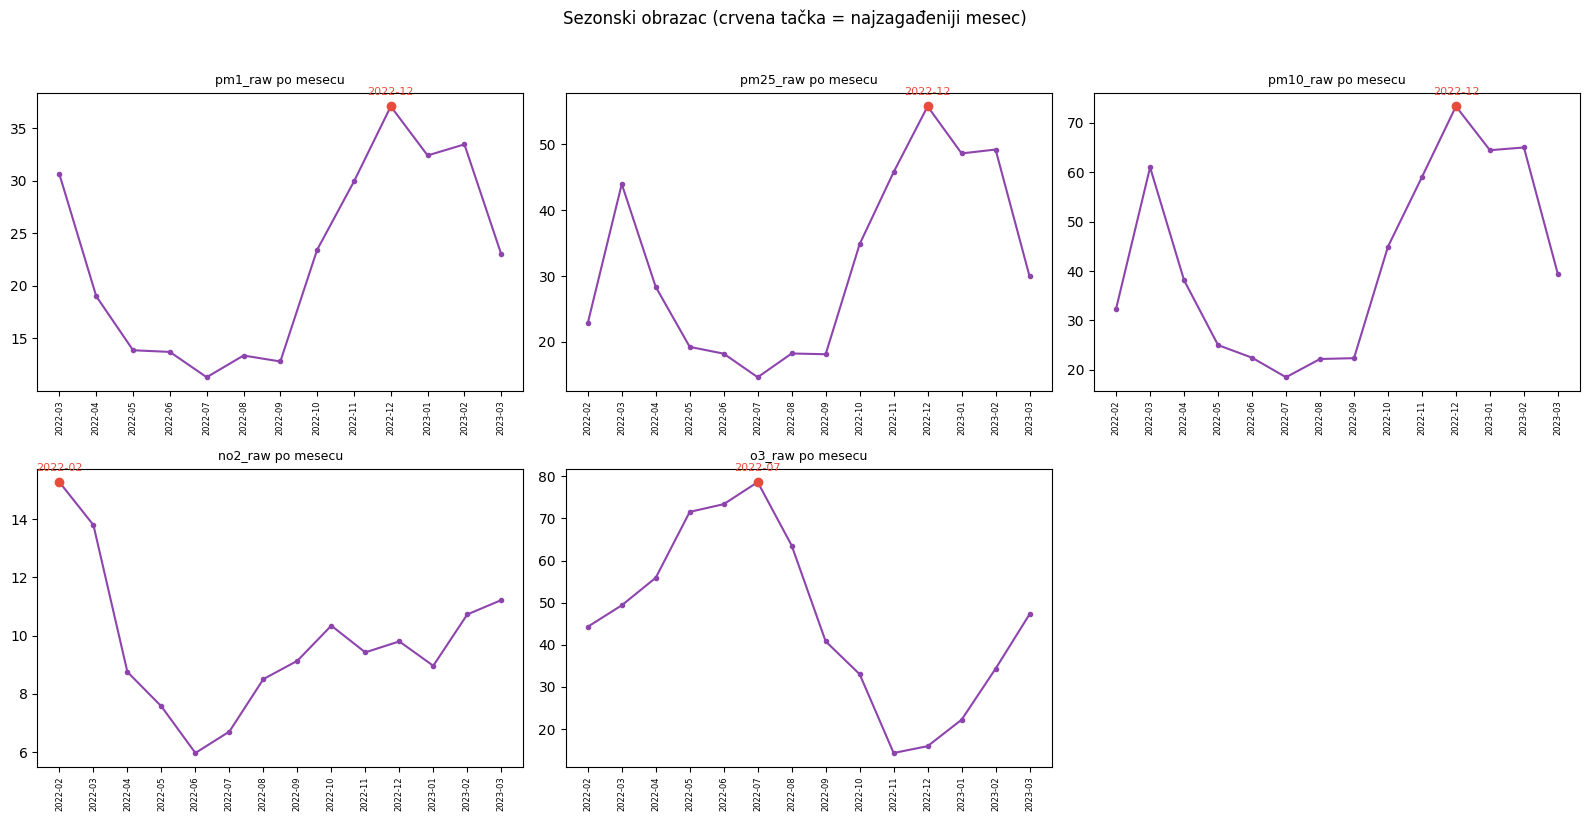

ZAKLJUČAK: Najzagađeniji mesec po PM2.5 je 2022-12 (55.8 µg/m³). Zimski meseci u proseku imaju 44.5 µg/m³ naspram 17.0 µg/m³ leti (2.6x više) — jasan grejni sezonski efekat.


In [15]:
df["month"] = df["timestamp"].dt.strftime("%Y-%m")
seasonal = df.groupby("month")[raw_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(raw_cols):
    axes[i].plot(seasonal.index, seasonal[col], color="#8e44ad", marker="o", markersize=3)
    peak_month = seasonal[col].idxmax()
    peak_val = seasonal[col].max()
    axes[i].scatter([peak_month], [peak_val], color="#e74c3c", zorder=5)
    axes[i].annotate(peak_month, (peak_month, peak_val), textcoords="offset points",
                      xytext=(0, 8), ha="center", fontsize=8, color="#e74c3c")
    axes[i].set_title(f"{col} po mesecu", fontsize=9)
    axes[i].tick_params(axis="x", rotation=90, labelsize=6)
for j in range(len(raw_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Sezonski obrazac (crvena tačka = najzagađeniji mesec)", y=1.02)
plt.tight_layout()
plt.show()

pm25_peak_month = seasonal["pm25_raw"].idxmax()
winter_months = [m for m in seasonal.index if m.split("-")[1] in ("11", "12", "01", "02")]
summer_months = [m for m in seasonal.index if m.split("-")[1] in ("06", "07", "08")]
winter_avg = seasonal.loc[winter_months, "pm25_raw"].mean() if winter_months else np.nan
summer_avg = seasonal.loc[summer_months, "pm25_raw"].mean() if summer_months else np.nan
add_finding(
    f"Najzagađeniji mesec po PM2.5 je {pm25_peak_month} ({seasonal['pm25_raw'].max():.1f} µg/m³). "
    f"Zimski meseci u proseku imaju {winter_avg:.1f} µg/m³ naspram {summer_avg:.1f} µg/m³ leti "
    f"({winter_avg / summer_avg:.1f}x više) — jasan grejni sezonski efekat."
)


## 7. Poređenje gradova — sa istaknutim najboljim/najgorim

ZAKLJUČAK: 1 grad(ova) nema nijedno merenje PM2.5 pa je izuzet iz rangiranja ispod (npr. senzor tog grada meri samo druge parametre).


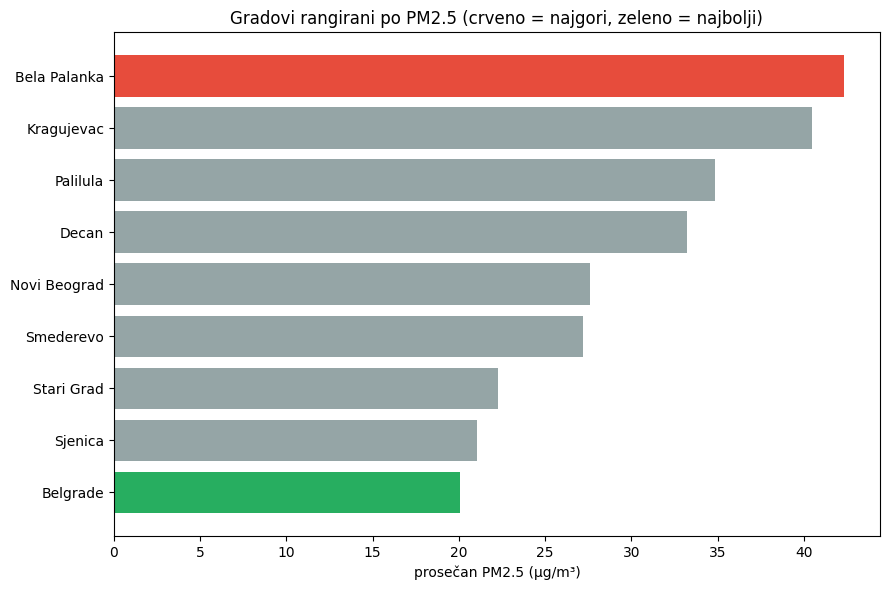

ZAKLJUČAK: Najzagađeniji grad po PM2.5 je Bela Palanka (42.3 µg/m³), najčistiji je Belgrade (20.0 µg/m³) — razlika je 2.1x.


In [16]:
city_avg = df.groupby("city")[raw_cols].mean().dropna(subset=["pm25_raw"]).sort_values("pm25_raw", ascending=False)

n_dropped = df["city"].nunique() - len(city_avg)
if n_dropped > 0:
    add_finding(
        f"{n_dropped} grad(ova) nema nijedno merenje PM2.5 pa je izuzet iz rangiranja ispod "
        "(npr. senzor tog grada meri samo druge parametre)."
    )

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#e74c3c" if c == city_avg.index[0] else
          "#27ae60" if c == city_avg.index[-1] else "#95a5a6"
          for c in city_avg.index]
ax.barh(city_avg.index, city_avg["pm25_raw"], color=colors)
ax.set_xlabel("prosečan PM2.5 (µg/m³)")
ax.set_title("Gradovi rangirani po PM2.5 (crveno = najgori, zeleno = najbolji)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

worst_city, best_city = city_avg.index[0], city_avg.index[-1]
ratio = city_avg.loc[worst_city, "pm25_raw"] / city_avg.loc[best_city, "pm25_raw"]
add_finding(
    f"Najzagađeniji grad po PM2.5 je {worst_city} ({city_avg.loc[worst_city, 'pm25_raw']:.1f} µg/m³), "
    f"najčistiji je {best_city} ({city_avg.loc[best_city, 'pm25_raw']:.1f} µg/m³) — "
    f"razlika je {ratio:.1f}x."
)


## 8. Dijagnostika senzora — vlažnost/temperatura vs. merenja

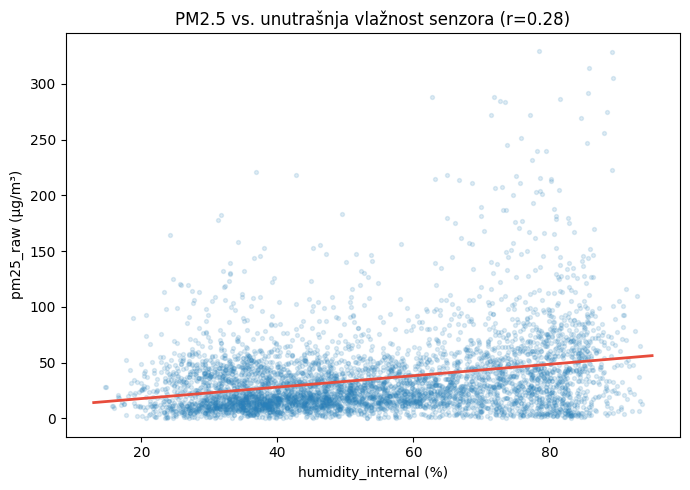

ZAKLJUČAK: Korelacija između unutrašnje vlažnosti senzora i PM2.5 očitavanja je slaba (r=0.28) — vlažnost ovde nije glavni izvor greške.


In [15]:
if "humidity_internal" in df.columns and "pm25_raw" in df.columns:
    paired = df[["humidity_internal", "pm25_raw"]].dropna()
    sample = paired.sample(min(5000, len(paired)), random_state=42)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sample["humidity_internal"], sample["pm25_raw"], alpha=0.15, s=8, color="#2980b9")
    corr_val = paired["humidity_internal"].corr(paired["pm25_raw"])
    z = np.polyfit(paired["humidity_internal"], paired["pm25_raw"], 1)
    xs = np.linspace(paired["humidity_internal"].min(), paired["humidity_internal"].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color="#e74c3c", linewidth=2)
    ax.set_xlabel("humidity_internal (%)")
    ax.set_ylabel("pm25_raw (µg/m³)")
    ax.set_title(f"PM2.5 vs. unutrašnja vlažnost senzora (r={corr_val:.2f})")
    plt.tight_layout()
    plt.show()

    strength = "jaka" if abs(corr_val) > 0.5 else "umerena" if abs(corr_val) > 0.3 else "slaba"
    add_finding(
        f"Korelacija između unutrašnje vlažnosti senzora i PM2.5 očitavanja je {strength} (r={corr_val:.2f}) — "
        f"{'sugeriše da vlažnost značajno iskrivljuje PM očitavanja, razmisliti o korekciji' if strength != 'slaba' else 'vlažnost ovde nije glavni izvor greške'}."
    )


## 9. AQI kategorije i dominantni zagađivač

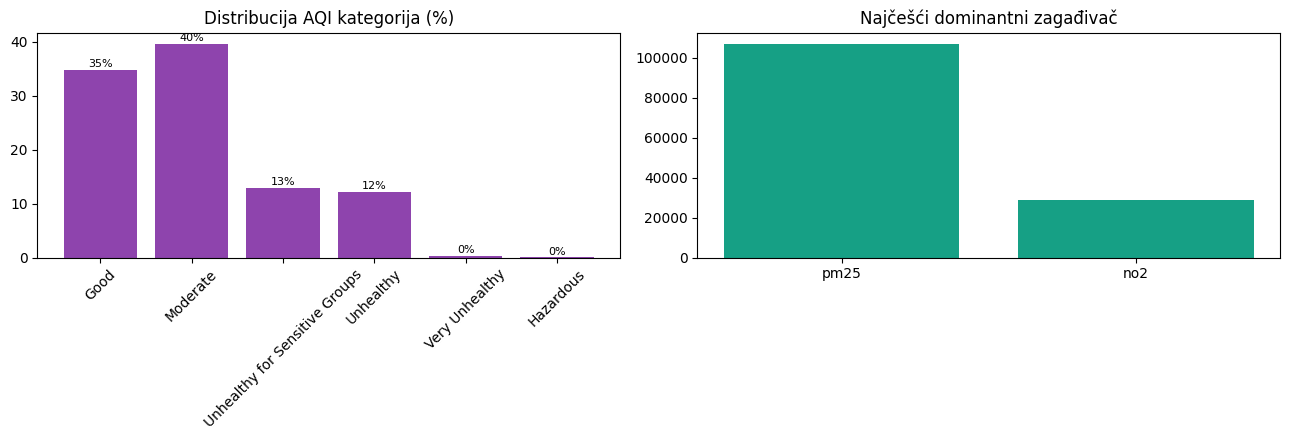

ZAKLJUČAK: 25% svih merenja spada u kategorije 'nezdravo' ili gore. Dominantni zagađivač je najčešće pm25 (79% slučajeva).


In [16]:
if "aqi" in existing_tables:
    aqi_df = pd.read_sql("SELECT * FROM aqi", conn)

    cat_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy",
                 "Very Unhealthy", "Hazardous"]
    cat_counts = aqi_df["aqi_category"].value_counts()
    cat_counts = cat_counts.reindex([c for c in cat_order if c in cat_counts.index]).fillna(0)
    cat_pct = cat_counts / cat_counts.sum() * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    bars = axes[0].bar(cat_counts.index, cat_pct.values, color="#8e44ad")
    axes[0].set_title("Distribucija AQI kategorija (%)")
    axes[0].tick_params(axis="x", rotation=45)
    for b, v in zip(bars, cat_pct.values):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)

    dom = aqi_df["dominant_pollutant"].value_counts()
    axes[1].bar(dom.index, dom.values, color="#16a085")
    axes[1].set_title("Najčešći dominantni zagađivač")
    plt.tight_layout()
    plt.show()

    unhealthy_pct = cat_pct.reindex(
        ["Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]
    ).sum()
    top_dominant = dom.idxmax()
    add_finding(
        f"{unhealthy_pct:.0f}% svih merenja spada u kategorije 'nezdravo' ili gore. "
        f"Dominantni zagađivač je najčešće {top_dominant} "
        f"({dom.max() / dom.sum() * 100:.0f}% slučajeva)."
    )
else:
    print("Tabela 'aqi' ne postoji u ovoj bazi — sekcija preskočena.")


In [17]:
conn.close()